In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer


from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Download required NLTK data
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Shreni\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shreni\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shreni\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shreni\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
df= pd.read_csv('C:/Users/Shreni/OneDrive/Desktop/AI-Product-Development/AIPD_Datasets/IMDB Dataset (1).csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [17]:
df.columns

Index(['review', 'sentiment'], dtype='str')

In [18]:
df['sentiment']= df['sentiment'].map({'positive':1, 'negative':0})

In [19]:
stop_words= set(stopwords.words('english'))

def clean_text(text):
    text= text.lower()
    text = re.sub(r'<.*?>', '', text)
    text= re.sub(r'[^a-zA-Z]',' ', text)
    tokens= word_tokenize(text)
    tokens= [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['clean_reviews']=df['review'].apply(clean_text)

In [22]:
vectorizer = TfidfVectorizer(max_features=5000)
x = vectorizer.fit_transform(df['clean_reviews'])
y = df['sentiment']

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)

In [25]:
nb = MultinomialNB()
nb.fit(x_train, y_train)
pred_nb = nb.predict(x_test)
print("Naive Bayes")

print("Accuracy:", accuracy_score(y_test, pred_nb))
print("Precision:", precision_score(y_test, pred_nb))
print("Recall:", recall_score(y_test, pred_nb))
print("F1 Score:", f1_score(y_test, pred_nb))

Naive Bayes
Accuracy: 0.8552
Precision: 0.8532362777887075
Recall: 0.8606866441754316
F1 Score: 0.8569452677336494


In [26]:
lr = LogisticRegression(max_iter=500)
lr.fit(x_train, y_train)
pred_lr = lr.predict(x_test)
print("Logistic Regression")

print("Accuracy:", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("Recall:", recall_score(y_test, pred_lr))
print("F1 Score:", f1_score(y_test, pred_lr))

Logistic Regression
Accuracy: 0.8925
Precision: 0.8827732715334106
Recall: 0.9071244294502877
F1 Score: 0.8947832044631496


In [28]:
svm = LinearSVC()
svm.fit(x_train, y_train)
pred_svm = svm.predict(x_test)
print("SVM")

print("Accuracy:", accuracy_score(y_test, pred_svm))
print("Precision:", precision_score(y_test, pred_svm))
print("Recall:", recall_score(y_test, pred_svm))
print("F1 Score:", f1_score(y_test, pred_svm))

SVM
Accuracy: 0.8821
Precision: 0.8756325418450759
Recall: 0.8928358801349474
F1 Score: 0.8841505355212734


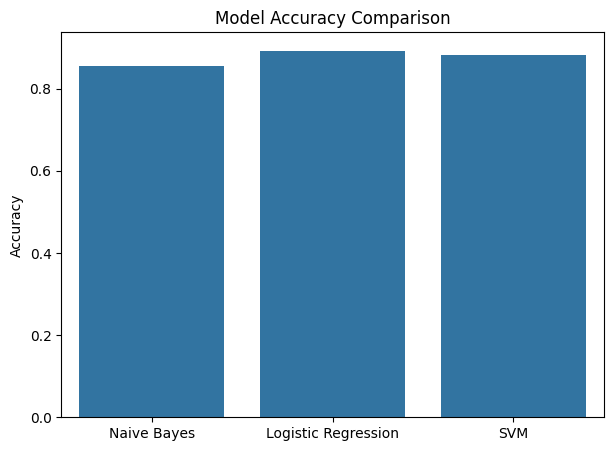

In [29]:
models = ['Naive Bayes','Logistic Regression','SVM']
accuracies = [
    accuracy_score(y_test, pred_nb),
    accuracy_score(y_test, pred_lr),
    accuracy_score(y_test, pred_svm)
]

plt.figure(figsize=(7,5))
sns.barplot(x=models, y=accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [30]:
review = input("Enter the review: ")
clean = clean_text(review)
vector = vectorizer.transform([clean])
prediction = svm.predict(vector)
if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Positive Review
